In [432]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import scipy.signal
from matplotlib.patches import Patch
from TIF import Info, Anotaciones

In [ ]:
class RawSignal:
    """
    Clase para manejar señales fisiológicas en formato NumPy.
    Este constructor permite inicializar el objeto 'RawSignal' a partir de un array de datos ,
    con información adicional de los canales y el índice de la primera muestra."""
    
    def __init__(self, data:np.ndarray, sfreq:float, info:Info=None, anotaciones:Anotaciones=None, first_samp:int=0):
        """
        Inicializa una instancia de la clase RawSignal.
        
        Args:
            data : Array de datos con forma '(n_canales , n_muestras)'.
            sfreq : Frecuencia de muestreo de la señal en Hz.
            info : Por defecto es None. Información adicional sobre la señal. El diccionario contiene info relevante de la señal
            anotaciones : Objeto de tipo Anotaciones que almacena eventos asociados a la señal y al experimento.
            first_samp : Índice del primer muestreo a utilizar (default es 0).
            
        Raises:
            ValueError : Si el array 'data' no tiene la forma '(n_canales , n_muestras)'.
            ValueError : Si el índice 'first_samp' está fuera del rango de la señal. """
        
        if not isinstance(data, np.ndarray):     # Que data sea un array de NumPy
            raise ValueError("El parámetro 'data' debe ser un array de NumPy (np.ndarray).")

        if data.ndim != 2:                       # Que data tenga dos dimensiones 
            raise ValueError("El array 'data' debe tener dos dimensiones: (n_canales, n_muestras).")

        n_muestras = data.shape[1]               # Número de muestras es la segunda dimensión
        if not (0 <= first_samp < n_muestras):   # Que first_samp sea un entero positivo y menor que el numero de muestras
            raise ValueError("El índice 'first_samp' está fuera del rango de muestras disponibles.")

        self.data = data
        self.sfreq = sfreq
        self.info = info
        self.first_samp = first_samp

        if anotaciones is not None:
            self.validar_anotaciones(anotaciones)    # Validación estructurada
            self.anotaciones = anotaciones
    

    def validar_anotaciones(self, anotaciones:Anotaciones):
        """
        Verifica que las anotaciones estén dentro del rango temporal de la señal.

        Args:
            anotaciones :  Objeto de la clase 'Anotaciones' que contiene la información de los eventos.

        Raises:
            TypeError : Si el parámetro 'anotaciones' no es una instancia de la clase 'Anotaciones'.
            ValueError : Si alguna anotación está fuera del rango temporal de la señal. """

        if not isinstance(anotaciones, Anotaciones):
            raise TypeError("El parámetro 'anotaciones' debe ser una instancia de la clase 'Anotaciones'.")

        df = anotaciones.get_annotations()                # Método de la clase Anotaciones

        duracion_total = (self.data.shape[1] / self.sfreq) + self.first_samp  # Duración total de la señal

        for i, fila in df.iterrows():                     # Validar que todas las anotaciones estén dentro del rango
            inicio = fila["Inicio"]
            duracion = fila["Duracion"]
            if not (0 <= inicio <= duracion_total):
                raise ValueError(f"Anotación con inicio en {inicio}s fuera del rango (0 - {duracion_total:.2f}s).")
            if inicio + duracion > duracion_total:
                raise ValueError(f"Anotación desde {inicio}s con duración {duracion}s excede el final de la señal.")

        self.anotaciones = anotaciones
    
    def set_anotaciones(self, anotaciones: Anotaciones):
        """
        Asocia o reemplaza el objeto 'Anotaciones' de la señal, validando que esté en rango.

        Args:
            anotaciones : Objeto de la clase 'Anotaciones' que contiene la información de los eventos.

        Raises:
            TypeError : Si el parámetro no es de tipo 'Anotaciones'.
            ValueError : Si alguna anotación está fuera del rango temporal de la señal.
        """
        self.validar_anotaciones(anotaciones)
        self.anotaciones = anotaciones
        
    def get_data(self, picks=None, start:float|int=0, stop:float|int=0, reject:float=None, times:bool=False):
        """
        Obtiene muestras de la señal en un rango dado.
        Args:
            picks (str o array_like) : Canales o índices a extraer. Si es 'None', se seleccionan todos los canales.
            start : Tiempo inicial (en segundos) para extraer muestras (por defecto 0).
            stop : Tiempo final (en segundos) para extraer muestras (por defecto 0, que significa hasta el final de la señal).
            reject : Valor pico a pico de umbral para rechazar canales. Si una muestra supera este umbral, el canal se descarta (por defecto 'None').
            times : Si es 'True', se retorna también el vector de tiempos asociado a las muestras.

        Returns:
            np.ndarray : Matriz con los datos seleccionados (n_canales x n_muestras).
            np.ndarray (opcional) : Vector de tiempos (solo si 'times=True').

        Raises
            ValueError : Si los índices seleccionados están fuera de rango. """
        
        n_canales, n_muestras = self.data.shape                       # Número de canales y muestras  
    
        start_idx = int(start * self.sfreq)                           # Convertir start de segundos a número de muestra
        stop_idx = int(stop * self.sfreq) if stop > 0 else n_muestras # Si stop es mayor que 0, convertir a indice de muestra, sino, tomar hasta el final

        if not (0 <= start_idx < stop_idx <= n_muestras):             # Si no se cumple que start_idx es mayor o igual a 0 y menor que stop_idx y ademas stop_idx es menor o igual al numero de muestras, lleva al error
            raise ValueError("Índices de tiempo fuera de rango.")

        # Seleccionar canales
        if picks is None:                             # Si picks queda por defecto, seleccionar todos los canales
            canales_idx = np.arange(n_canales)

        elif isinstance(picks, (list, np.ndarray)):
            if all(isinstance(pick, int) for pick in picks):   # Verificar que los canales ingresados sean todos enteros
                if np.isin(picks, np.arange(n_canales)).all(): # Verificar si los canales ingresados existen
                    canales_idx = np.array(picks)
                else:
                    raise ValueError("Error: algunos canales ingresados no existen")
            
            elif all(isinstance(pick, str) for pick in picks):   # Verificar que los canales ingresados sean todos strings
                if self.info is None:
                    raise ValueError("Debe ingresar el objeto Info")
                
                nombres = self.info.get("Nombre canales")       # Aplicamos el médoto de Info para obtener los canales del diccionario
                try:
                    canales_idx = [nombres.index(canal) for canal in picks] # Si "canal" esta en los canels pasados desde Info, obtiene el indice y se agrega a canales_idx
                except ValueError:
                    raise ValueError(f"Error: uno o más canales no se encuentran en los canales Ingresados desde el objeto Info")
            else:
                raise ValueError("Error: los canales ingresados no tienen el mismo formato")

        else:
            raise ValueError("Formato de 'picks' inválido. Deben ser strings o enteros.")

        datos = self.data[np.array(canales_idx), start_idx : stop_idx]  # Extraer datos de los canales

        if reject is not None:                 # Aplicar umbral de rechazo si se especifica
            pico_pico = np.ptp(datos, axis=1)  # Toma el max y min del canal y los resta, obteniendo el valor pico_pico de cada canal (axis=1 filas)
            filtro = pico_pico < reject        # Filtro para quedarme solo con los valores pico_pico menores a reject
            datos = datos[filtro]

        if times is True:
            tiempo_vector = (np.arange(start_idx, stop_idx) / self.sfreq) + self.first_samp
            
            return datos, tiempo_vector

        return datos
        
    def crop(self, tmin:int|float=0.0, tmax:int|float=None) -> "RawSignal":
        """
        Obtiene un trozo de RawSignal. Limita los datos dentro de RawSignal
        para obtener un nuevo objeto RawSignal pero con una cantidad de muestras recortadas.
        
        Args:
            tmin : Tiempo inicial en segundos para iniciar el recorte (por defecto es 0.0).
            tmax : Tiempo final en segundos para finalizar el recorte (por defecto es None).
        
        Returns:
            RawSignal : Nueva instancia de 'RawSignal' que contiene el segmento temporal recortado.
        
        Raises
            Value Error : Si los tiempos 'tmin' o 'tmax' están fuera del rango de la señal. """
        
        n_canales, n_muestras = self.data.shape
        duracion_total = n_muestras / self.sfreq

        anotaciones_copia = copy.deepcopy(self.anotaciones)
        anotaciones_copia.recorte(tmin=tmin, tmax=tmax)               # Elimina las anotaciones que superan el tmax del recorte

        # Validaciones
        if not isinstance(tmin, (int, float)) or tmin < 0:             # Si tmin no es entero, flotante o positivo
            raise ValueError("'tmin' debe ser un número positivo.")
        
        if tmax is not None:
            if not isinstance(tmax, (int, float)) or tmax <= tmin:     # Si tmax no es un número o es menor a tmin
                raise ValueError("'tmax' debe ser mayor que 'tmin'.")
            elif tmax > duracion_total:                                # Si tmax es mayor que la duracion total de la señal
                raise ValueError(f"'tmax' está fuera del rango de la señal ({duracion_total:.2f} s).")

        if tmin > duracion_total:                                      #Chequeo si tmin es mayor que la duracion total de la señal 
            raise ValueError(f"'tmin' está fuera del rango de la señal ({duracion_total:.2f} s).")

        start_idx = int(tmin * self.sfreq)                             # Convertir a índices
        end_idx = int(tmax * self.sfreq) if tmax is not None else n_muestras

        datos_crop = self.data[:, start_idx:end_idx]                   # De todos los canales (:), extraer el segmento de la señal (start_idx:end_idx)

        return RawSignal(data=datos_crop, sfreq=self.sfreq, info=self.info, anotaciones=anotaciones_copia, first_samp=tmin) # El segmento recortado empieza en 0 (first_samp)
    
    def drop_channels(self, ch_names:list|np.ndarray) -> "RawSignal":
        """ 
        Elimina uno o más canales a partir de ch_names.

        Args:
            ch_names : Nombres de canales a eliminar

        Returns:
            Objeto RawSignal """

        # Validaciones
        if self.info is None or self.info.get("Nombre canales") is None:
            raise ValueError("No se puede eliminar canales sin el objeto Info o los nombres de los canales")
        
        canales_actuales = self.info["Nombre canales"]
        datos_actuales = self.data
        info_copia = copy.deepcopy(self.info)

        if all(isinstance(ch, str) for ch in ch_names):    # Si todos los canales son str
            try:
                indices_eliminar = [canales_actuales.index(nombre) for nombre in ch_names]
            except ValueError as e:
                raise ValueError(f"Uno o más nombres de canal no se encuentran en la lista: {e}")
            
        elif all(isinstance(ch, int) for ch in ch_names):  # Si todos los canales son int
            indices_eliminar = ch_names
        
        else:
            raise ValueError("Todos los elementos de 'ch_names' deben ser del mismo tipo (str o int).")
        
        datos_filtrados = np.delete(datos_actuales, indices_eliminar, axis=0)   # Elimina los indices (canales) de la señal

        info_copia.eliminar_elementos(key="Nombre canales", elementos=ch_names)

        return RawSignal(data=datos_filtrados, sfreq=self.sfreq, info=info_copia, anotaciones=self.anotaciones)

    def describe(self, archivo_salida):
        """
        Genera un DataFrame con estadísticas descriptivas para cada canal de la señal.

        Para cada canal se obtiene:
        - Nombre: Nombre del canal.
        - Tipo: Tipo de canal (eeg, ecg, emg).
        - Min: Valor mínimo del canal.
        - Q1: Primer cuartil (percentil 25%).
        - Mediana: Mediana (percentil 50%).
        - Q3: Tercer cuartil (percentil 75%).
        - Max: Valor máximo del canal.

        Args:
            archivo_salida : Nombre del archivo csv que se genera

        Returns:
            pd.DataFrame : Tabla con una fila por estadístico y una columna por canal. """
        
        n_canales = 0

        if self.info is not None:
            if "Nombre canales" in self.info:
                nombres = self.info.get("Nombre canales")
                n_canales = len(nombres)

            if "Tipo canales" in self.info:
                tipos = self.info.get("Tipo canales")
        
        if self.info is None: 
            n_canales = self.data.shape[0]
            nombres = [f"Canal_{i}" for i in range(n_canales)]
            tipos = ["Desconocido"] * n_canales
        
        tabla = {}

        for i in range(n_canales):
            canal = self.data[i]
            resumen = {
                "Nombre canal": nombres[i],
                "Tipo canal": tipos[i],
                "Min": np.min(canal),
                "Q1": np.percentile(canal, 25),
                "Mediana": np.median(canal),
                "Q3": np.percentile(canal, 75),
                "Max": np.max(canal) }
            tabla[nombres[i]] = resumen

        datos = pd.DataFrame(tabla)
        datos.to_csv(archivo_salida, index=False)

        return datos

    def filter(self, l_freq:float, h_freq:float, notch_freq:float = 50.0, order:int = 4) -> "RawSignal":
        """
        Aplica un filtro pasabanda (Butterworth) y un filtro notch a la señal fisiológica.
        El filtro notch permite eliminar una frecuencia fija (por defecto 50 Hz).
        Filtro pasabanda Butterworth que permite mantener solo las frecuencias entre l_freq y h_freq.

        Args:
            l_freq : Frecuencia de corte baja del filtro pasabanda (en Hz).
            h_freq : Frecuencia de corte alta del filtro pasabanda (en Hz).
            notch_freq : Frecuencia del filtro notch para eliminar ruido (por defecto 50 Hz).
            order : Orden del filtro Butterworth (por defecto 4).

        Returns:
            RawSignal : Nueva instancia de RawSignal con los datos filtrados.

        Raises:
            ValueError : Si las frecuencias de corte no son válidas. """
        
        if l_freq >= h_freq:
            raise ValueError("La frecuencia de corte mínima debe ser menor que la de corte máxima.")
        
        if notch_freq <= 0 or l_freq <= 0 or h_freq <= 0:
            raise ValueError("Las frecuencias deben ser mayores que cero.")

        datos_filtrados = np.empty_like(self.data)   # Crear un nuevo array para almacenar los datos filtrados. empty_like: Return a new array with the same shape and type as a given array.

        # Diseño del filtro notch
        Q = 30.0  # Factor de calidad del notch (más alto = más estrecho)
        b_notch, a_notch = scipy.signal.iirnotch(notch_freq, Q, self.sfreq)

        # Diseño del filtro pasabanda Butterworth
        b_band, a_band = scipy.signal.butter(order, [l_freq, h_freq], btype='band', fs=self.sfreq)

        for i in range(self.data.shape[0]):                                           # Aplica los filtros a cada canal de la señal
            canal = self.data[i]                                                      # Extraer un canal
            canal_filtrado = scipy.signal.filtfilt(b_notch, a_notch, canal)           # Aplica notch
            canal_filtrado = scipy.signal.filtfilt(b_band, a_band, canal_filtrado)    # Aplica pasabanda
            datos_filtrados[i] = canal_filtrado                                       # Guarda resultado

        return RawSignal(data=datos_filtrados, sfreq=self.sfreq, info=self.info, anotaciones=self.anotaciones, first_samp=self.first_samp)

    def pick(self, canales=None, slice:list=None) -> "RawSignal":
        """
        Retorna un subset de canales seleccionados.

        Args:
            canales : Lista con los canales para armar el subset. Por defecto es None.
                Puede ser:
                    - list[str] : lista de nombres de canales
                    - list[int] : lista de índices de canales
            
            slice : Lista con los extremos para hacer slicing. Por defecto es None.
            
        Returns:
            RawSignal : Nueva instancia con los canales seleccionados.

        Raises: ValueError:
                    Si el canal especificado no existe.
                    Si el índice está fuera del rango de canales. """
        

        if canales is not None and slice is None:
            indices = canales

        elif canales is None and slice is not None:
            indices = list(range(slice[0], slice[1]))

        else:
            raise ValueError ("Error: debe ingresar canales o slice. No se permiten los dos al mismo tiempo")
        
        if self.info is not None:
            subset = self.get_data(picks=indices)
            info_copia = copy.deepcopy(self.info)
            canales_originales = info_copia.get("Nombre canales")
            for canal in canales_originales:
                if canal not in indices:
                    info_copia.eliminar_elementos("Nombre canales", elementos= [canal])
        else:
            subset = self.get_data(picks=indices)
            info_copia = None

        return RawSignal(data=subset, sfreq=self.sfreq, info=info_copia, anotaciones=self.anotaciones, first_samp=self.first_samp)    

    def plot(self, picks=None, start:float=0, duration:float=None, show_anotaciones:bool=True):

        """
        Grafica un segmento de la señal fisiológica.

        Args:
            Canal o canales a visualizar. Puede ser:
                - list[str]: lista de nombres de canales,
                - list[int]: lista de índices de canales.
                - Si es None, se grafican todos los canales.

            start : Tiempo inicial (en segundos) desde donde comenzar la visualización (por defecto 0.0).
            duration : Duración del segmento de señal a mostrar en segundos, por defecto None, gráfica toda la señal).

            show_anotaciones (por defecto True): 
                    True : Se muestran las anotaciones sobre la señal.
                    False : No se muestran las anotaciones.
        """  
        
        if duration is None:
            n_muestras = self.data.shape[1]
            duration = n_muestras / self.sfreq

        # El tiempo relativo en el objeto recortado siempre empieza en 0
        intervalo_inicio = start
        intervalo_fin = start + duration

        canales, tiempo = self.get_data(picks=picks, start=intervalo_inicio, stop=intervalo_fin, times=True)
        n_canales = canales.shape[0]

        fig, axes = plt.subplots(n_canales, 1, figsize=(10, 3 * n_canales), sharex=True)
        if n_canales == 1:
            axes = [axes]

        for i in range(n_canales):
            axes[i].plot(tiempo, canales[i])
            axes[i].set_ylabel(f"Canal {i}")
            axes[i].set_xlabel("Tiempo [s]")
            axes[i].grid(True)

        # El eje x debe mostrar los tiempos absolutos (first_samp + tiempo relativo)
        x_min = self.first_samp + intervalo_inicio
        x_max = self.first_samp + intervalo_fin

        if show_anotaciones and self.anotaciones is not None:
            df = self.anotaciones.get_annotations()
            eventos = df["Descripcion"].unique()
            colormap = plt.colormaps.get_cmap('Set1')  # 'rainbow', 'Set3', cool, plasma

            # Asignar un color único a cada tipo de evento
            colores_eventos = {evento: colormap(i / len(eventos)) for i, evento in enumerate(eventos)}

            for evento, color in colores_eventos.items():
                df_filtrado = df[df["Descripcion"] == evento]

                for _, fila in df_filtrado.iterrows():
                    inicio = fila["Inicio"]
                    duracion = fila["Duracion"]
                    fin = inicio + duracion
                    if (inicio < x_max) and (fin > x_min):
                        sombra_inicio = max(inicio, x_min)
                        sombra_fin = min(fin, x_max)
                        for ax in axes:
                            ax.axvspan(sombra_inicio, sombra_fin, color=color, alpha=0.3)

            handles = [Patch(color=color, label=evento) for evento, color in colores_eventos.items()]
            fig.legend(handles=handles, loc='upper right')
            
        plt.xlim(x_min, x_max)
        plt.tight_layout()
        plt.show()
    
    def __getitem__(self):
        pass

In [434]:
eeg_data = np.load("../2. tests/eeg/eeg_signal.npy")

In [435]:
eeg_data.shape

(62, 388047)

In [436]:
# Esto era para ver nomas que habia en el archivo
eeg = pd.DataFrame(eeg_data)
eeg.head()

,0,1,2,3,4,5,6,7,8,9,...,388037,388038,388039,388040,388041,388042,388043,388044,388045,388046
0,3.058463,69.378151,512.287476,2046.245483,5376.158691,10384.538086,15923.265625,20547.367188,23392.972656,24475.962891,...,-178.895386,-173.085815,-164.276978,-152.824463,-141.760376,-135.108521,-135.037842,-141.609375,-154.146606,-171.841797
1,2.483788,56.613033,418.650482,1673.291016,4397.784668,8496.500000,13029.791992,16814.097656,19141.298828,20024.503906,...,-34.890717,-32.244675,-26.992029,-20.398066,-14.261873,-10.162393,-8.862572,-10.432716,-14.530706,-20.378460
2,1.720225,39.700825,294.783447,1180.238525,3104.773193,6001.839844,9207.491211,11883.846680,13528.648438,14150.855469,...,-172.516739,-169.558792,-165.001038,-154.812500,-138.597839,-121.553047,-111.058151,-111.978516,-124.081688,-142.575546
3,2.277081,85.158783,690.347961,2849.392334,7594.347656,14776.036133,22754.841797,29451.494141,33609.718750,35234.156250,...,-101.200439,-109.095215,-101.527100,-79.137939,-51.548828,-31.460693,-26.456543,-36.743652,-58.282227,-85.846191
4,2.820107,69.279091,522.174072,2102.081055,5542.711914,10726.230469,16464.289062,21257.328125,24206.724609,25327.796875,...,-33.257740,-30.782782,-25.127575,-17.920855,-11.455353,-7.688463,-7.410977,-10.375611,-15.825042,-22.785292


In [437]:
# Genero objeto Info

canales = ["F2", "F3", "F4"]
tipos_canales = ["eeg"] * len(canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

infoo = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=canales, 
        ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Claves:", infoo.keys())
print("Canales iniciales:", infoo.data["Nombre canales"])

Claves: ['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo']
Canales iniciales: ['F2', 'F3', 'F4']


In [438]:
# Genero objeto Anotaciones, mediante anotaciones "manuales"

inicio = [5.0, 12.5, 20.0]
duracion = [2.0, 3.0, 3.5]
descripcion = ['Inicio_Experimento', 'Evento_1', 'Evento_2']
anotacioness = Anotaciones(onset=inicio, duration=duracion, description=descripcion)
anotacioness.get_annotations()

,Inicio,Duracion,Descripcion
0,5.0,2.0,Inicio_Experimento
1,12.5,3.0,Evento_1
2,20.0,3.5,Evento_2


In [525]:
# Generar el objeto RawSignal
raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness) 

In [526]:
# Obtener muestas con get_data()

# muestras = raw_signal.get_data(start=0, stop=1)   # Sin pasar los canales los selecciona a todos
# muestras, vector = raw_signal.get_data(picks=[0,1,2], start=0, stop=10, times=True, reject=30000)
# print(muestras.shape)
# print(vector)

muestras = raw_signal.get_data(picks=["F2", "F3"], start=0, stop=20)  
print(muestras.shape)

(2, 10240)


In [441]:
# Elimina el canal "F2"
nueva_rawsignal = raw_signal.drop_channels(["F2"])

In [442]:
# Verifico que la nueva instancia de RawSignal elimino un canal
print("Canales restantes:", nueva_rawsignal.info["Nombre canales"])

Canales restantes: ['F3', 'F4']


In [443]:
# Uso la nueva instancia RawSignal y selecciono los dos canales que quedaron
print(nueva_rawsignal.get_data(picks=["F3", "F4"], start=0, stop=10).shape)  

(2, 5120)


In [444]:
# Recortar la señal (tiempo). Método crop() desde el primer objeto Rawsignal

rawsignal_recortada = raw_signal.crop(tmin= 5, tmax=50)   # Recorte
datos, tiempo = rawsignal_recortada.get_data(picks=["F2", "F3"], start=0, stop=5, times=True)
print(datos.shape)
print("Vector temporal:", tiempo)

(2, 2560)
Vector temporal: [5.         5.00195312 5.00390625 ... 9.99414062 9.99609375 9.99804688]


In [445]:
# Metodo describe() con la primar instancia de RawSignal que tiene el Objeto Info

raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness)
# muestras = raw_signal_2.get_data(picks=["A2", "F3"], start=0, stop=100)
datos = raw_signal.describe("Datos.csv")
datos

,F2,F3,F4
Nombre canal,F2,F3,F4
Tipo canal,eeg,eeg,eeg
Min,-8707.160156,-7117.736328,-7099.595703
Q1,-7.417814,-4.250395,-5.601849
Mediana,0.036089,0.011847,0.064424
Q3,7.569031,4.314002,5.865489
Max,24475.962891,20024.503906,20075.072266


In [446]:
# Metodo describe() sin el Objeto Info. Si no le paso este objeto veo todos los canales y el Tipo de canal se establece en desconocido

raw_signal_sinInfo = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)
datos2 = raw_signal_sinInfo.describe("Datos2.csv")
datos2

,Canal_0,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,...,Canal_52,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61
Nombre canal,Canal_0,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,...,Canal_52,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,...,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,7.569031,4.314002,5.865489,13.503281,5.290212,4.608644,4.702813,5.650655,5.634275,5.804526,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


In [447]:
# Metodo pick()

canales = ["A2", "F3", "F4"]
tipos_canales = ["eeg"] * len(canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

info2 = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=canales,
            ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Canales iniciales:", info2.data["Nombre canales"])
print()

raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, info=info2, anotaciones=anotacioness)

# Aca se genera el subset con el metodo pick()
subset = raw_signal_2.pick(canales=["A2", "F3"])            # Le pasamos los canales que queremos en una lista (canales)
print("Canales del subset:", subset.info["Nombre canales"])
datos = subset.describe("Datoss.csv")                       # Usamos describe para ver algunos datos del subset
datos

Canales iniciales: ['A2', 'F3', 'F4']

Canales del subset: ['A2', 'F3']


,A2,F3
Nombre canal,A2,F3
Tipo canal,eeg,eeg
Min,-8707.160156,-7117.736328
Q1,-7.417814,-4.250395
Mediana,0.036089,0.011847
Q3,7.569031,4.314002
Max,24475.962891,20024.503906


In [448]:
# Metodo pick(). Sin el objeto Info (toma los 62 canales) y usando "slice"

raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)

subset = raw_signal_2.pick(slice=[0,4])       # Obtenemos los canales de 0 a 4. (El 4 no se incluye)
# subset = raw_signal_2.pick(canales=[0,2,4])
asd = subset.get_data()
asd.shape
datos = subset.describe("Datoss.csv")   # Vemos algunos datos de los canales seleccionados 
datos

,Canal_0,Canal_1,Canal_2,Canal_3
Nombre canal,Canal_0,Canal_1,Canal_2,Canal_3
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375
Q1,-7.417814,-4.250395,-5.601849,-12.632099
Mediana,0.036089,0.011847,0.064424,0.535278
Q3,7.569031,4.314002,5.865489,13.503281
Max,24475.962891,20024.503906,20075.072266,35234.15625


In [449]:
# Generamos un nuevo onjeto Anotaciones. Esta vez se cargan desde un archivo csv
anotaciones_file = Anotaciones(file="../2. tests/eeg/eventos_ejemplo.csv")
anotaciones_file.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


In [450]:
# Cambiamos las anotaciones RawSignal
raw_signal_2.set_anotaciones(anotaciones_file)

In [ ]:
# Recordando que Info esta definido asi
canales = ["F2", "F3", "F4"]
tipos_canales = ["eeg"] * len(canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

infoo = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=canales,
            ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

In [ ]:
# Instanciamos otro objeto RawSignal. Le pasamos Info y las Anotaciones que cargamos del archivo
signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotaciones_file)

# Vemos algunas de las anotaciones
signal.anotaciones.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


In [473]:
# Recortamos "signal"
recorte_señal = signal.crop(tmin=35, tmax=60)
recorte_señal.info.get("Nombre canales")

['F2', 'F3', 'F4']

In [474]:
# Vemos el vector de tiempo para verificar que recortamos la señal 
d, t = recorte_señal.get_data(picks=["F2"], times=True)
t

array([35.        , 35.00195312, 35.00390625, ..., 59.99414062,
       59.99609375, 59.99804688])

In [475]:
# Verificamos que tambien se recortaron las anotaciones 
recorte_señal.anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA


In [480]:
print("first_samp:", recorte_señal.first_samp)
print("sfreq:", recorte_señal.sfreq)
print("Duración de la señal :", recorte_señal.data.shape[1] / recorte_señal.sfreq)

first_samp: 35
sfreq: 512
Duración de la señal : 25.0


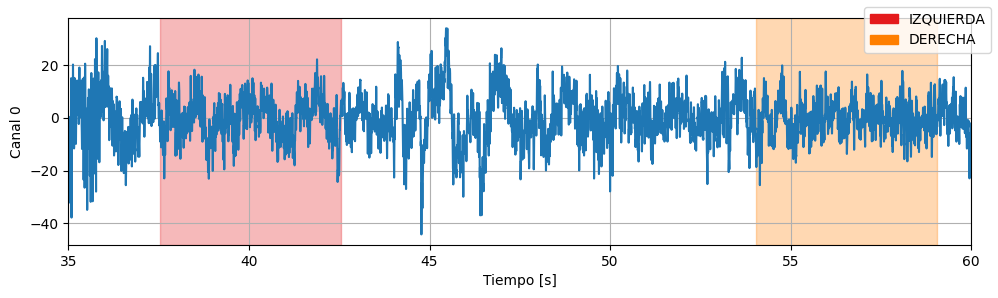

In [476]:
# Gráficamos nuestra señal recortada
recorte_señal.plot(picks=["F2"], show_anotaciones=True)

In [478]:
# Filtramos la señal
filtrada = recorte_señal.filter(l_freq=20, h_freq=100)

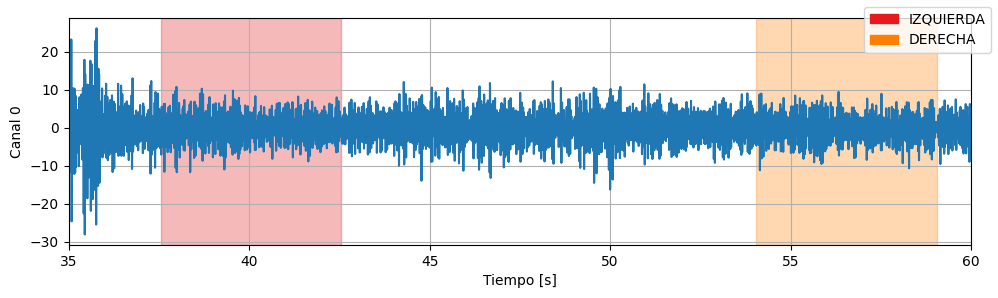

In [ ]:
# Graficarmos la señal filtrada
filtrada.plot(picks=["F2"])

In [ ]:
class EEG(RawSignal):
    """
    Clase para representar y analizar una señal de Electroencefalografía (EEG).

    Proporciona herramientas básicas para manipular y visualizar señales EEG, aplica filtrado espacial,
    y realiza análisis espectrales y temporales.

    """

    def __init__(self, data: np.ndarray, sfreq: float, info: Info = None, anotaciones: Anotaciones = None, first_samp: int = 0,
                referencia: str = "promedio"):
        super().__init__(data, sfreq, info, anotaciones, first_samp)

        self.referencia = referencia

    def set_reference(self, reference: str, channel: str|int = None):
        """
        Cambia la referencia de la señal EEG. Opciones disponibles: 'canal', 'promedio' , 'laplaciano'.".

        """

        self.referencia = reference

        if self.referencia == "canal":
            self.data_ref = self._aplicar_referencia_a_canal(channel=channel)
        
        elif self.referencia == "promedio":
            self.data_ref = self._aplicar_referencia_promedio()

        elif self.referencia == "laplaciano":
            pass

        else:
            raise ValueError("Tipo de referencia no reconocida. Debe usar 'canal', 'promedio' o 'laplaciano'.")
        
        return self.data_ref

    def _aplicar_referencia_a_canal(self, channel: str|int):
        """
        Cambia la referencia de todos los canales a un canal específico.

        Este método resta, muestra a muestra, la señal de un canal de referencia seleccionado al resto de los canales EEG. 

        """

        canales_disponibles = self.info.get("Nombre canales")

        if channel in canales_disponibles:
            channel_values = self.get_data([channel])
            reference = self.data - channel_values

        else:
            raise ValueError (f"El canal {channel} no existe. Canales disponibles: {canales_disponibles}")
        
        return reference

    def _aplicar_referencia_promedio(self):
        """
        Aplica una referencia promedio a la señal EEG.

        Este método calcula el promedio de todos los canales en cada muestra de tiempo
        y lo resta a cada canal individual, generando así una señal referenciada al promedio.
        """

        channel_values = self.get_data() 
        mean_reference = np.mean(channel_values, axis=0)
        reference = self.data - mean_reference
        return reference


    def _aplicar_referencia_laplaciana(self):
        """
        Aplica una referencia Laplaciana espacial a la señal EEG.

        Este método calcula la diferencia entre la señal de un canal central y la media de sus canales vecinos.

        """

        pass

    def apply_laplacian_filter(self):
        """
        Aplica un filtro espacial Laplaciano para resaltar la actividad local de cada canal.

        """

        pass

    def plot_fourier_spectrum(self):
        """
        Calcula y grafica el espectro de Fourier de uno o varios canales de la señal EEG.

        """

        pass
    
    def plot_time_frequency(self):
        """
        Calcula y grafica una representación tiempo-frecuencia de un canal específico

        """

        pass

    def plot_hilbert_transform(self):
        """
        Calcula y grafica la transformada de Hilbert de uno o varios canales, mostrando la envolvente.

        """

        pass

In [530]:
nombre_canales = ["F2", "F3", "F4"]
tipos_canales = ["eeg"] * len(canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

info_eeg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512 )

anotaciones_file = Anotaciones(file="../2. tests/eeg/eventos_ejemplo.csv")

eeg_data = np.load("../2. tests/eeg/eeg_signal.npy")

In [531]:
# Instanciar clase EEG

eeg = EEG(data=eeg_data, sfreq=512, info=info_eeg, anotaciones=anotaciones_file, first_samp=0, referencia="canal")

In [540]:
ref = eeg.set_reference(reference="canal", channel="F2")
ref.shape
ref

array([[   0.       ,    0.       ,    0.       , ...,    0.       ,
           0.       ,    0.       ],
       [  -0.5746753,  -12.765118 ,  -93.63699  , ...,  131.17667  ,
         139.6159   ,  151.46333  ],
       [  -1.338238 ,  -29.677326 , -217.50403  , ...,   29.63086  ,
          30.064919 ,   29.26625  ],
       ...,
       [  -1.1684313,  -30.213924 , -229.69666  , ...,  155.28632  ,
         161.75755  ,  172.2258   ],
       [  -1.0229466,  -15.522961 , -101.13843  , ...,  158.99017  ,
         165.43266  ,  175.30049  ],
       [  -3.2502143,  -73.55899  , -542.74176  , ...,  129.55713  ,
         141.43158  ,  157.6486   ]], dtype=float32)

In [541]:
ref_promedio = eeg.set_reference(reference="promedio")
ref_promedio.shape
ref_promedio

array([[ 1.4938390e+00,  2.6415298e+01,  1.8100632e+02, ...,
        -1.3114218e+02, -1.3610907e+02, -1.4536543e+02],
       [ 9.1916370e-01,  1.3650181e+01,  8.7369324e+01, ...,
         3.4472466e-02,  3.5068340e+00,  6.0979023e+00],
       [ 1.5560102e-01, -3.2620277e+00, -3.6497711e+01, ...,
        -1.0151133e+02, -1.0604414e+02, -1.1609918e+02],
       ...,
       [ 3.2540774e-01, -3.7986259e+00, -4.8690338e+01, ...,
         2.4144123e+01,  2.5648493e+01,  2.6860365e+01],
       [ 4.7089243e-01,  1.0892338e+01,  7.9867889e+01, ...,
         2.7847984e+01,  2.9323593e+01,  2.9935053e+01],
       [-1.7563753e+00, -4.7143692e+01, -3.6173544e+02, ...,
        -1.5850506e+00,  5.3225126e+00,  1.2283164e+01]], dtype=float32)